# Phase 4: Feature Engineering

**Project:** CogniLend – Loan Approval Decision-Support System
**Inputs (from Phase 3):**
- `data/processed/cleaned_dataset_original_units.csv` – clean data in real units (used to **build** new features)
- `data/processed/semi_preprocessed_dataset.csv` – model-ready columns (already capped / log / scaled / encoded)
- `phase3/transform_params.json` – values used in Phase 3

**Outputs:**
- `data/final/final_preprocessed_dataset.csv` – **final deliverable** (ready for the model)
- `phase4/feature_params.json` – how every final feature was made (formulas, caps, scaler values, selection reasons)

**Tasks in this phase:** feature construction, feature selection, feature extraction.
Cleaning, filling and encoding were finished in Phase 3. For the **new** features we reuse the Phase 3 transform rules
(cap → log1p if skew > 1 → StandardScaler), as the Phase 3 hand-over asked.

## Step 0: Import libraries and load the Phase 3 outputs

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

MAIN_COLOR = '#2a78d6'      # blue   -> kept / normal
SECOND_COLOR = '#eb6834'    # orange -> dropped / problem
GREY = '#b5b5b5'

sns.set_style('whitegrid')
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['grid.color'] = '#e6e6e6'
plt.rcParams['axes.edgecolor'] = '#999999'

PLOT_DIR = 'plots'
FINAL_DIR = '../data/final'
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(FINAL_DIR, exist_ok=True)


def save_plot(file_name):
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, file_name), dpi=150, bbox_inches='tight')
    plt.show()


print('scikit-learn version:', sklearn.__version__)

scikit-learn version: 1.8.0


In [2]:
clean = pd.read_csv('../data/processed/cleaned_dataset_original_units.csv')
semi = pd.read_csv('../data/processed/semi_preprocessed_dataset.csv')
with open('../phase3/transform_params.json') as f:
    phase3_params = json.load(f)

print('Clean (real units):', clean.shape)
print('Semi-preprocessed :', semi.shape)
print('Same rows in the same order:', (clean['Loan_ID'].values == semi['loan_id'].values).all())

y = clean['Loan_Status']
print('Approval rate: %.2f%%' % (y.mean() * 100))

Clean (real units): (9847, 17)
Semi-preprocessed : (9847, 26)
Same rows in the same order: True
Approval rate: 58.46%


## Part A: Feature construction

Phase 2 showed that most columns are weak **alone**, but strong **when compared with each other** (loan vs income, EMI vs income,
loan vs collateral, age + tenure). Indian banks also decide on such ratios. So we build these features **from the real-unit file**:

| New feature | Formula | Bank meaning | Phase 2 evidence |
|---|---|---|---|
| `total_income` | Monthly_Income + Coapplicant_Income | Income used for eligibility | Co-applicant income raises approval (55.6% → 66.6%) |
| `proposed_emi` | P·r·(1+r)^n / ((1+r)^n − 1) | EMI of the new loan | 12-month tenures (big EMI) only 38% approved |
| `foir` | (Existing_EMI + proposed_emi) / total_income | Fixed Obligation to Income Ratio | EMI matters only compared with income (D4) |
| `collateral_coverage` | Collateral_Value / Loan_Amount (0 = unsecured) | Inverse of LTV | Above the RBI LTV limit: 2.8% vs 57.1% (D5) |
| `loan_to_income` | Loan_Amount / (12 × total_income) | Loan size in years of income | Small loan + high income 81.6% vs big loan + low income 36.7% (D3) |
| `age_at_maturity` | Age + Loan_Tenure / 12 | Age when the last EMI is paid | Age 61+ → 24.4%, 360 months → 32.6% |
| `has_coapplicant` | Coapplicant_Income > 0 | Has an earning co-applicant | Candidate flag |
| `is_secured` | Collateral_Value > 0 | Loan has collateral | Candidate flag |

For the EMI: P = Loan_Amount, n = tenure in months, r = yearly rate ÷ 12. Rates are typical bank rates for each loan type
(Home 8.5%, Vehicle 9.5%, Personal 11.5%, Business 13%). We use one fixed rate per type because the real rate is only fixed **after** approval.

In [3]:
yearly_rate = {'Home': 0.085, 'Vehicle': 0.095, 'Personal': 0.115, 'Business': 0.130}
r = clean['Loan_Type'].map(yearly_rate) / 12        # monthly rate
n = clean['Loan_Tenure']                            # months

new = pd.DataFrame()
new['total_income'] = clean['Monthly_Income'] + clean['Coapplicant_Income']
new['proposed_emi'] = clean['Loan_Amount'] * r * (1 + r) ** n / ((1 + r) ** n - 1)
new['foir'] = (clean['Existing_EMI'] + new['proposed_emi']) / new['total_income']
new['collateral_coverage'] = clean['Collateral_Value'] / clean['Loan_Amount']
new['loan_to_income'] = clean['Loan_Amount'] / (12 * new['total_income'])
new['age_at_maturity'] = clean['Age'] + n / 12
new['has_coapplicant'] = (clean['Coapplicant_Income'] > 0).astype(int)
new['is_secured'] = (clean['Collateral_Value'] > 0).astype(int)

new.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
total_income,9847.0,87149.832,71028.218,8000.000,42300.000,67700.000,109300.000,1072200.000
proposed_emi,9847.0,24990.111,29989.545,1050.093,8087.593,15925.707,30647.828,629066.084
foir,9847.0,0.357,0.231,0.007,0.199,0.312,0.462,3.295
collateral_coverage,9847.0,0.879,0.812,0.000,0.000,1.130,1.417,16.683
loan_to_income,9847.0,1.370,1.334,0.015,0.477,0.800,1.991,15.583
age_at_maturity,9847.0,45.264,10.850,21.000,37.000,45.000,53.000,94.000
has_coapplicant,9847.0,0.321,0.467,0.000,0.000,0.000,1.000,1.000
is_secured,9847.0,0.596,0.491,0.000,0.000,1.000,1.000,1.000


In [4]:
# small check with one applicant, by hand
row = 0
print('Applicant:', clean.loc[row, 'Loan_ID'], '| loan type:', clean.loc[row, 'Loan_Type'])
print('Loan Rs.', clean.loc[row, 'Loan_Amount'], 'for', clean.loc[row, 'Loan_Tenure'], 'months')
print('Proposed EMI     : Rs. %.0f' % new.loc[row, 'proposed_emi'])
print('Existing EMI     : Rs. %.0f' % clean.loc[row, 'Existing_EMI'])
print('Total income     : Rs. %.0f' % new.loc[row, 'total_income'])
print('FOIR             : %.1f%%' % (new.loc[row, 'foir'] * 100))
print('Collateral cover : %.2f x the loan' % new.loc[row, 'collateral_coverage'])
print('Age at maturity  : %.1f years' % new.loc[row, 'age_at_maturity'])

Applicant: LN2025102971 | loan type: Home
Loan Rs. 1440000.0 for 240 months
Proposed EMI     : Rs. 12497
Existing EMI     : Rs. 1900
Total income     : Rs. 45800
FOIR             : 31.4%
Collateral cover : 1.44 x the loan
Age at maturity  : 60.0 years


**Result (construction):** 8 new features were built from real values.
- **Hand check, first applicant:** a home loan of ₹14.4 lakh over 240 months gives an **EMI of ₹12,497**. With an existing EMI of ₹1,900 and income of ₹45,800, that is **FOIR = 31.4%**. The collateral covers **1.44×** the loan, and the applicant will be **60** at the last EMI. These values are realistic.
- Before capping:
  - FOIR median 31.2%, max 330%
  - loan-to-income median 0.8 years, max 15.6 years
  - collateral coverage max 16.7×
  - age at maturity 21 to 94
- 32.1% of applicants have an earning co-applicant and 59.6% of loans are secured.

### A2. Treat extreme values of the new features (Phase 3 rule, applied to new features)
The ratios were built from **real** values first. Only now do we cap them, so that a capped income cannot make FOIR wrong.

| Feature | Cap | Why |
|---|---|---|
| `total_income` | 1st / 99th percentile | Same rule as the Phase 3 money columns |
| `foir` | 0 to 1.5 | Above 150% of income the EMI is clearly unpayable. A bigger number adds no information |
| `collateral_coverage` | 0 to 5.0 | Collateral worth more than 5× the loan is already "very safe" |
| `loan_to_income` | 0 to 99th percentile | No clear bank limit, so we use the data's 99th percentile |
| `age_at_maturity` | none | Already in a normal range (about 21–86 years) |

In [5]:
caps = {}
low = new['total_income'].quantile(0.01)
high = new['total_income'].quantile(0.99)
n_capped = ((new['total_income'] < low) | (new['total_income'] > high)).sum()
new['total_income'] = new['total_income'].clip(low, high)
caps['total_income'] = [float(low), float(high)]
print('total_income capped to [', round(low), ',', round(high), '] -> values changed:', n_capped)

ratio_caps = {'foir': 1.5, 'collateral_coverage': 5.0, 'loan_to_income': new['loan_to_income'].quantile(0.99)}
for col in ratio_caps:
    high = ratio_caps[col]
    n_capped = (new[col] > high).sum()
    new[col] = new[col].clip(0, high)
    caps[col] = [0.0, float(high)]
    print(col, 'capped to [ 0 ,', round(high, 2), '] -> values changed:', n_capped)

total_income capped to [ 14000 , 359258 ] -> values changed: 197
foir capped to [ 0 , 1.5 ] -> values changed: 29
collateral_coverage capped to [ 0 , 5.0 ] -> values changed: 5
loan_to_income capped to [ 0 , 5.62 ] -> values changed: 99


### A3. Do the new features separate Approved from Rejected?
Approval rate for groups of each new feature (real values, after capping).

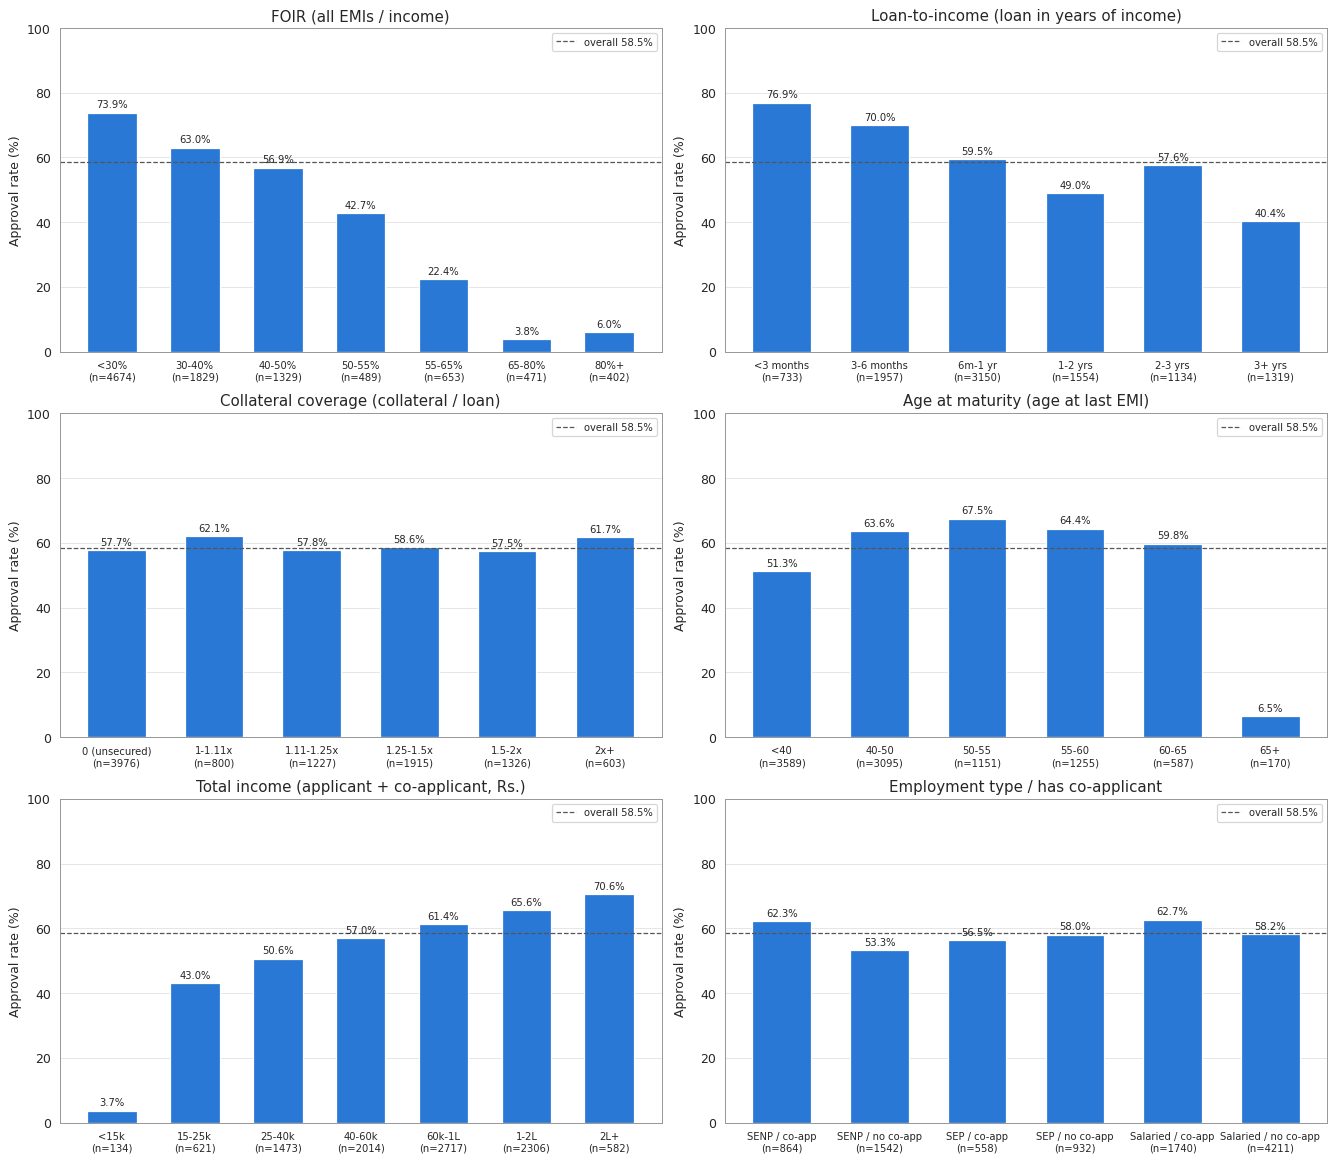

FOIR groups:
         mean  count
foir                
<30%    0.739   4674
30-40%  0.630   1829
40-50%  0.569   1329
50-55%  0.427    489
55-65%  0.224    653
65-80%  0.038    471
80%+    0.060    402

Age-at-maturity groups:
                  mean  count
age_at_maturity              
<40              0.513   3589
40-50            0.636   3095
50-55            0.675   1151
55-60            0.644   1255
60-65            0.598    587
65+              0.065    170

Collateral coverage groups:
                      mean  count
collateral_coverage              
0 (unsecured)        0.577   3976
1-1.11x              0.621    800
1.11-1.25x           0.578   1227
1.25-1.5x            0.586   1915
1.5-2x               0.575   1326
2x+                  0.617    603


In [6]:
OVERALL = y.mean() * 100


def draw_rate(ax, groups, title):
    table = y.groupby(groups, observed=True).agg(['mean', 'count'])
    labels = []
    for name, count in zip(table.index, table['count']):
        labels.append(str(name) + '\n(n=' + str(count) + ')')
    rates = table['mean'] * 100
    bars = ax.bar(labels, rates, color=MAIN_COLOR, width=0.6)
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, rate + 1.5, str(round(rate, 1)) + '%', ha='center', fontsize=8)
    ax.axhline(OVERALL, color='#555555', linestyle='--', linewidth=1, label='overall ' + str(round(OVERALL, 1)) + '%')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(0, 100)
    ax.set_title(title)
    ax.set_ylabel('Approval rate (%)')
    ax.xaxis.grid(False)
    ax.tick_params(axis='x', labelsize=8)
    return table


fig, axes = plt.subplots(3, 2, figsize=(15, 13))
foir_groups = pd.cut(new['foir'], [-0.01, 0.3, 0.4, 0.5, 0.55, 0.65, 0.8, 1.5],
                     labels=['<30%', '30-40%', '40-50%', '50-55%', '55-65%', '65-80%', '80%+'])
foir_table = draw_rate(axes[0, 0], foir_groups, 'FOIR (all EMIs / income)')

lti_groups = pd.cut(new['loan_to_income'], [-0.01, 0.25, 0.5, 1, 2, 3, 10],
                    labels=['<3 months', '3-6 months', '6m-1 yr', '1-2 yrs', '2-3 yrs', '3+ yrs'])
lti_table = draw_rate(axes[0, 1], lti_groups, 'Loan-to-income (loan in years of income)')

cover_groups = pd.cut(new['collateral_coverage'], [-0.01, 0, 1.11, 1.25, 1.5, 2, 5],
                      labels=['0 (unsecured)', '1-1.11x', '1.11-1.25x', '1.25-1.5x', '1.5-2x', '2x+'])
cover_table = draw_rate(axes[1, 0], cover_groups, 'Collateral coverage (collateral / loan)')

mat_groups = pd.cut(new['age_at_maturity'], [0, 40, 50, 55, 60, 65, 100],
                    labels=['<40', '40-50', '50-55', '55-60', '60-65', '65+'])
mat_table = draw_rate(axes[1, 1], mat_groups, 'Age at maturity (age at last EMI)')

inc_groups = pd.cut(new['total_income'], [0, 15000, 25000, 40000, 60000, 100000, 200000, 1000000],
                    labels=['<15k', '15-25k', '25-40k', '40-60k', '60k-1L', '1-2L', '2L+'])
inc_table = draw_rate(axes[2, 0], inc_groups, 'Total income (applicant + co-applicant, Rs.)')

coapp_text = new['has_coapplicant'].map({1: 'co-app', 0: 'no co-app'})
flag_groups = clean['Employment_Type'] + ' / ' + coapp_text
flag_table = draw_rate(axes[2, 1], flag_groups, 'Employment type / has co-applicant')
save_plot('p4_new_features_vs_target.png')

print('FOIR groups:')
print(foir_table.round(3))
print()
print('Age-at-maturity groups:')
print(mat_table.round(3))
print()
print('Collateral coverage groups:')
print(cover_table.round(3))

**Result (do the new features work?):**

| Feature | What we see | Matches |
|---|---|---|
| **FOIR** | <30% → **73.9%** approval; 55–65% → 22.4%; 65–80% → **3.8%** | The FOIR limit of 50–65% (rule R4). The strongest new feature |
| **Total income** | Below ₹15k → **3.7%** (n = 134). Above that it rises smoothly to 70.6% | Minimum income (R6). Much sharper than Phase 2's 17.9% for applicant income alone, so the rule really uses **total** income |
| **Age at maturity** | 65+ → **6.5%** (n = 170); up to 60–65 still 59.8% | Age at loan end ≤ 60/65 (R2) |
| **Loan-to-income** | Below 3 months of income → 76.9%; over 3 years → 40.4% | Phase 2 finding: loan size compared with income |
| **Collateral coverage** | Almost flat (57.5–62.1%) **when used alone** | The RBI LTV rule applies only to **home loans**, and its limit depends on the loan size. So coverage works **together with loan type**. The random forest still ranks it 4th (see B1) |
| Employment × co-applicant | A co-applicant helps SENP (62.3% vs 53.3%) and Salaried (62.7% vs 58.2%) | Small effect |

The ratios separate Approved and Rejected **much better** than their parts did in Phase 2.

## Part B: Feature selection

### B0. Build the list of candidate features
- **Protected attributes are never candidates.** The 7 `gender_*` and `marital_*` columns from Phase 3 stay only for the fairness audit
  (RBI Fair Practices Code; Phase 2 issues P22, P23). `loan_id` is not a feature.
- For **scoring** the candidates we use real-unit values. Mutual information and random forests do not need scaling, and the scaled versions are used only at the end.
- CIBIL uses −1 → 739 (Phase 3 rule), with `is_new_to_credit` from Phase 3.

In [7]:
protected_cols = []
for col in semi.columns:
    if col.startswith('gender_') or col.startswith('marital_'):
        protected_cols.append(col)
print('Protected (audit only, never candidates):', protected_cols)

cibil_real = clean['CIBIL_Score'].replace(-1, phase3_params['cibil_ntc_replacement'])

cand = pd.DataFrame({
    'age': clean['Age'],
    'dependents': clean['Dependents'],
    'work_experience': clean['Work_Experience'],
    'monthly_income': clean['Monthly_Income'],
    'coapplicant_income': clean['Coapplicant_Income'],
    'total_income': new['total_income'],
    'existing_emi': clean['Existing_EMI'],
    'cibil_score': cibil_real,
    'is_new_to_credit': semi['is_new_to_credit'],
    'loan_amount': clean['Loan_Amount'],
    'loan_tenure_months': clean['Loan_Tenure'],
    'proposed_emi': new['proposed_emi'],
    'foir': new['foir'],
    'collateral_value': clean['Collateral_Value'],
    'collateral_coverage': new['collateral_coverage'],
    'loan_to_income': new['loan_to_income'],
    'age_at_maturity': new['age_at_maturity'],
    'has_coapplicant': new['has_coapplicant'],
    'is_secured': new['is_secured'],
    'property_area': semi['property_area'],
    'emp_senp': semi['emp_senp'],
    'emp_sep': semi['emp_sep'],
    'loan_type_business': semi['loan_type_business'],
    'loan_type_home': semi['loan_type_home'],
    'loan_type_vehicle': semi['loan_type_vehicle'],
})
print('Number of candidate features:', cand.shape[1])
print(list(cand.columns))

Protected (audit only, never candidates): ['gender_female', 'gender_transgender', 'gender_unknown', 'marital_single', 'marital_divorced', 'marital_widowed', 'marital_unknown']
Number of candidate features: 25
['age', 'dependents', 'work_experience', 'monthly_income', 'coapplicant_income', 'total_income', 'existing_emi', 'cibil_score', 'is_new_to_credit', 'loan_amount', 'loan_tenure_months', 'proposed_emi', 'foir', 'collateral_value', 'collateral_coverage', 'loan_to_income', 'age_at_maturity', 'has_coapplicant', 'is_secured', 'property_area', 'emp_senp', 'emp_sep', 'loan_type_business', 'loan_type_home', 'loan_type_vehicle']


### B1. Score every candidate
We use three simple measures:
1. **Mutual information (MI)** with the target: how much a feature tells us about approval (0 = nothing).
2. **Permutation importance (PI)** from a random forest: how much accuracy drops when the feature is shuffled (on a 25% test part).
3. **Spearman correlation** between features: to find pairs that carry the same information.

In [8]:
discrete = []
for col in cand.columns:
    discrete.append(cand[col].nunique() <= 5)      # 0/1 flags and small groups are treated as discrete

mi = pd.Series(mutual_info_classif(cand, y, discrete_features=discrete, random_state=0), index=cand.columns)

X_train, X_test, y_train, y_test = train_test_split(cand, y, test_size=0.25, stratify=y, random_state=0)
forest = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=0, n_jobs=-1)
forest.fit(X_train, y_train)
result = permutation_importance(forest, X_test, y_test, n_repeats=10, random_state=0, n_jobs=-1)
pi = pd.Series(result.importances_mean, index=cand.columns)

scores = pd.DataFrame({'MI': mi.round(4), 'PI': pi.round(4)}).sort_values('MI', ascending=False)
scores

,MI,PI
foir,0.1178,0.1376
cibil_score,0.1068,0.1231
work_experience,0.0677,0.0615
age,0.0387,0.0049
age_at_maturity,0.0378,0.0156
loan_to_income,0.0302,0.0054
proposed_emi,0.0238,0.0021
total_income,0.0189,0.0121
monthly_income,0.0169,0.0030
loan_tenure_months,0.0138,0.0013


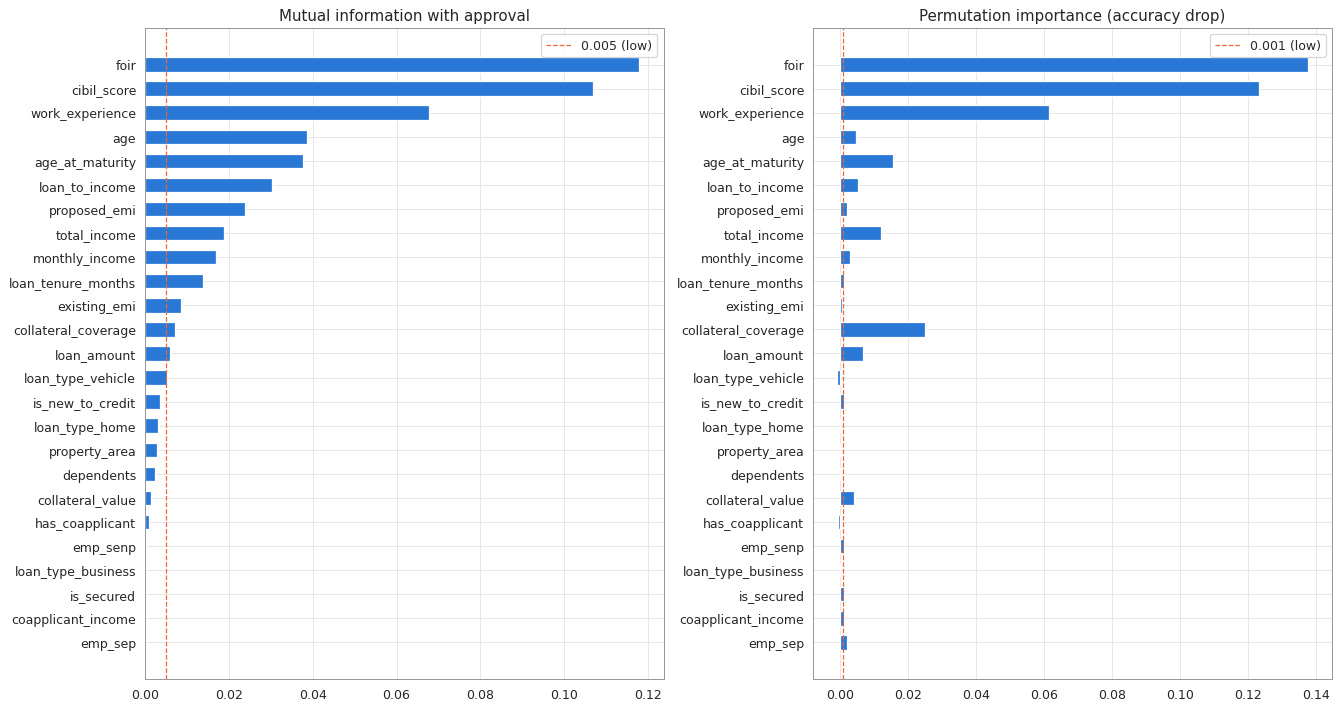

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
order = scores.index[::-1]
axes[0].barh(order, scores.loc[order, 'MI'], color=MAIN_COLOR, height=0.6)
axes[0].axvline(0.005, color=SECOND_COLOR, linestyle='--', linewidth=1, label='0.005 (low)')
axes[0].set_title('Mutual information with approval')
axes[0].legend()
axes[1].barh(order, scores.loc[order, 'PI'], color=MAIN_COLOR, height=0.6)
axes[1].axvline(0.001, color=SECOND_COLOR, linestyle='--', linewidth=1, label='0.001 (low)')
axes[1].set_title('Permutation importance (accuracy drop)')
axes[1].legend()
save_plot('p4_feature_scores.png')

In [10]:
corr = cand.corr(method='spearman').abs()
pairs = []
columns = list(cand.columns)
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        value = corr.iloc[i, j]
        if value > 0.80:
            pairs.append([columns[i], columns[j], round(value, 3)])
pairs = sorted(pairs, key=lambda p: p[2], reverse=True)
print('Pairs with |Spearman| > 0.80:')
for p in pairs:
    print('  ', p[0], '<->', p[1], ':', p[2])

Pairs with |Spearman| > 0.80:
   coapplicant_income <-> has_coapplicant : 0.976
   age <-> work_experience : 0.937
   collateral_value <-> collateral_coverage : 0.886
   collateral_value <-> is_secured : 0.879
   collateral_coverage <-> is_secured : 0.879
   monthly_income <-> total_income : 0.874
   loan_amount <-> proposed_emi : 0.85
   loan_amount <-> loan_to_income : 0.814


In [11]:
# importance of the one-hot GROUPS (shuffle all columns of a group together)
groups = {
    'employment_type': ['emp_senp', 'emp_sep'],
    'loan_type': ['loan_type_business', 'loan_type_home', 'loan_type_vehicle'],
}
base_accuracy = forest.score(X_test, y_test)
rng = np.random.default_rng(0)
group_pi = {}
for name in groups:
    cols = groups[name]
    drops = []
    for k in range(10):
        shuffled = X_test.copy()
        shuffled[cols] = X_test[cols].values[rng.permutation(len(X_test))]
        drops.append(base_accuracy - forest.score(shuffled, y_test))
    group_pi[name] = round(float(np.mean(drops)), 4)
print('Random forest test accuracy:', round(base_accuracy, 4))
print('Group permutation importance:', group_pi)

Random forest test accuracy: 0.8741
Group permutation importance: {'employment_type': 0.004, 'loan_type': 0.0011}


**Result (scores):**
- **Top by both measures:** `foir` (MI 0.118, PI 0.138), `cibil_score` (0.107, 0.123) and `work_experience` (0.068, 0.062). Next come `collateral_coverage` (PI 0.025), `age_at_maturity` and `total_income`.
- **Redundant pairs (|ρ| > 0.80):**
  - coapplicant_income ↔ has_coapplicant (0.98)
  - **age ↔ work_experience (0.94)**
  - collateral_value ↔ collateral_coverage (0.89)
  - is_secured ↔ collateral (0.88)
  - monthly_income ↔ total_income (0.87)
  - loan_amount ↔ proposed_emi (0.85)
  - loan_amount ↔ loan_to_income (0.81)
- **Group importance:** employment type 0.0040, loan type 0.0011. One-hot columns look weak one by one, but they matter as a group.
- Random forest test accuracy: 0.874.

### B2. The selection funnel
We remove features step by step. Every removed feature gets a written reason.

| Step | Rule |
|---|---|
| **A. Ratio replaces its parts** | Banks decide on ratios, so the parts of a ratio are dropped: monthly_income, coapplicant_income (→ total_income), existing_emi, proposed_emi (→ foir), collateral_value (→ collateral_coverage), loan_amount (→ loan_to_income) |
| **B. Redundancy** | If two remaining features have \|Spearman\| > 0.80, drop the one with lower MI |
| **C. Relevance** | Drop a feature if **both** MI < 0.005 **and** PI < 0.001 |
| **D. One-hot groups** | Keep a group if its group PI ≥ 0.001 |
| **Must-keep (safety rule)** | Steps C and D never drop a feature that a **bank rule (R1–R7)** needs. Then a bank rule can always be explained with model features, and small score changes on another computer cannot change the final list |

Must-keep list (bank rule it supports): `cibil_score` + `is_new_to_credit` (R3), `foir` (R4), `collateral_coverage` (R5), `age_at_maturity` (R2),
`total_income` (R6), `work_experience` + employment group (R7, R2), loan-type group (R5 applies to home loans).

In [12]:
must_keep = ['cibil_score', 'is_new_to_credit', 'foir', 'collateral_coverage', 'age_at_maturity',
             'total_income', 'work_experience', 'emp_senp', 'emp_sep',
             'loan_type_business', 'loan_type_home', 'loan_type_vehicle']

dropped = {}     # feature -> reason

# Step A: ratio replaces its parts
step_a = {
    'monthly_income': 'part of total_income',
    'coapplicant_income': 'part of total_income',
    'existing_emi': 'part of foir',
    'proposed_emi': 'part of foir',
    'collateral_value': 'replaced by collateral_coverage (does not depend on loan size)',
    'loan_amount': 'replaced by loan_to_income (does not depend on loan size)',
}
for col in step_a:
    dropped[col] = 'A: ' + step_a[col]

left = []
for col in cand.columns:
    if col not in dropped:
        left.append(col)
print('After step A:', len(left), 'features')

# Step B: redundancy (strongest pair first)
for p in pairs:
    a = p[0]
    b = p[1]
    if a in left and b in left:
        if mi[a] < mi[b]:
            loser, keeper = a, b
        else:
            loser, keeper = b, a
        dropped[loser] = 'B: |rho| = ' + str(p[2]) + ' with ' + keeper + ', lower MI (' + str(round(mi[loser], 4)) + ' vs ' + str(round(mi[keeper], 4)) + ')'
        left.remove(loser)
print('After step B:', len(left), 'features')

# Step C: relevance
group_cols = groups['employment_type'] + groups['loan_type']
for col in list(left):
    if col in group_cols:
        continue
    if mi[col] < 0.005 and pi[col] < 0.001:
        if col in must_keep:
            print('   kept by must-keep rule:', col)
            continue
        dropped[col] = 'C: low relevance (MI = ' + str(round(mi[col], 4)) + ', PI = ' + str(round(pi[col], 4)) + ')'
        left.remove(col)
print('After step C:', len(left), 'features')

# Step D: one-hot groups
for name in groups:
    if group_pi[name] < 0.001:
        if groups[name][0] in must_keep:
            print('   group kept by must-keep rule:', name)
            continue
        for col in groups[name]:
            dropped[col] = 'D: group ' + name + ' has low importance (' + str(group_pi[name]) + ')'
            left.remove(col)
print('After step D:', len(left), 'features')

selected = []
for col in cand.columns:
    if col not in dropped:
        selected.append(col)

drop_table = pd.DataFrame({'feature': list(dropped.keys()), 'reason': list(dropped.values())})
print()
print('Selected features (' + str(len(selected)) + '):', selected)
drop_table

After step A: 19 features
After step B: 17 features
After step C: 14 features
After step D: 14 features

Selected features (14): ['work_experience', 'total_income', 'cibil_score', 'is_new_to_credit', 'loan_tenure_months', 'foir', 'collateral_coverage', 'loan_to_income', 'age_at_maturity', 'emp_senp', 'emp_sep', 'loan_type_business', 'loan_type_home', 'loan_type_vehicle']


,feature,reason
0,monthly_income,A: part of total_income
1,coapplicant_income,A: part of total_income
2,existing_emi,A: part of foir
3,proposed_emi,A: part of foir
4,collateral_value,A: replaced by collateral_coverage (does not d...
5,loan_amount,A: replaced by loan_to_income (does not depend...
6,age,"B: |rho| = 0.937 with work_experience, lower M..."
7,is_secured,"B: |rho| = 0.879 with collateral_coverage, low..."
8,dependents,"C: low relevance (MI = 0.0025, PI = 0.0002)"
9,has_coapplicant,"C: low relevance (MI = 0.0009, PI = -0.0006)"


In [13]:
# the must-keep rule as a check: which must-keep features were close to the cut-off?
for col in ['is_new_to_credit', 'loan_tenure_months']:
    print(col, '-> MI:', round(mi[col], 4), '| PI:', round(pi[col], 4))
print('loan_type group PI:', group_pi['loan_type'], '| employment group PI:', group_pi['employment_type'])

is_new_to_credit -> MI: 0.0036 | PI: 0.0013
loan_tenure_months -> MI: 0.0138 | PI: 0.0013
loan_type group PI: 0.0011 | employment group PI: 0.004


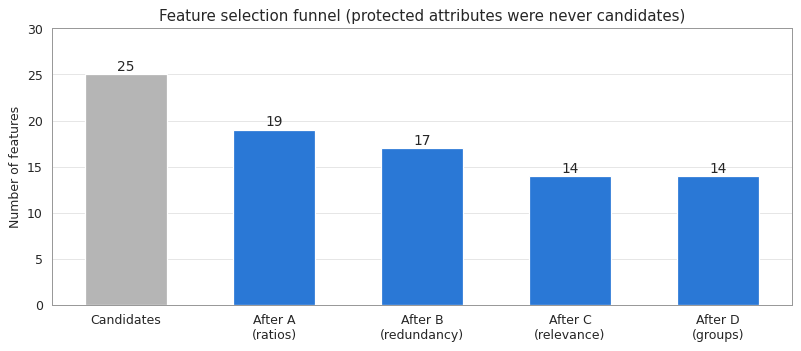

[25, 19, 17, 14, 14]


In [14]:
steps = ['Candidates', 'After A\n(ratios)', 'After B\n(redundancy)', 'After C\n(relevance)', 'After D\n(groups)']
counts = [cand.shape[1]]
for letter in ['A', 'B', 'C', 'D']:
    n_dropped = 0
    for reason in dropped.values():
        if reason.startswith(letter + ':'):
            n_dropped = n_dropped + 1
    counts.append(counts[-1] - n_dropped)

plt.figure(figsize=(9, 4))
bars = plt.bar(steps, counts, color=[GREY, MAIN_COLOR, MAIN_COLOR, MAIN_COLOR, MAIN_COLOR], width=0.55)
for bar, value in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.4, str(value), ha='center', fontsize=11)
plt.ylim(0, 30)
plt.ylabel('Number of features')
plt.title('Feature selection funnel (protected attributes were never candidates)')
plt.gca().xaxis.grid(False)
save_plot('p4_selection_funnel.png')
print(counts)

Highest |Spearman| between two selected features: 0.784


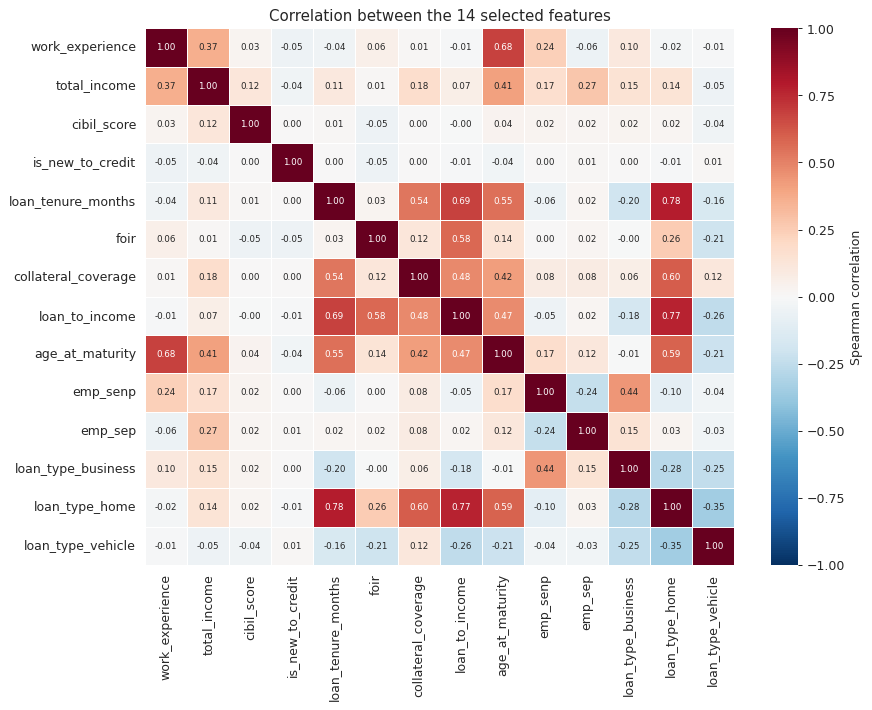

In [15]:
max_corr = cand[selected].corr(method='spearman').abs()
for i in range(len(selected)):
    max_corr.iloc[i, i] = 0
print('Highest |Spearman| between two selected features:', round(max_corr.max().max(), 3))

plt.figure(figsize=(10, 8))
sns.heatmap(cand[selected].corr(method='spearman'), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'fontsize': 7}, cbar_kws={'label': 'Spearman correlation'})
plt.title('Correlation between the 14 selected features')
save_plot('p4_selected_correlation.png')

### B3. Does the selection lose accuracy?
Same random forest, 5-fold cross-validation: all candidates vs the selected features.

In [16]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
forest_cv = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=0, n_jobs=-1)
acc_all = cross_val_score(forest_cv, cand, y, cv=folds).mean()
acc_selected = cross_val_score(forest_cv, cand[selected], y, cv=folds).mean()
print('Accuracy with all', cand.shape[1], 'candidates : %.4f' % acc_all)
print('Accuracy with', len(selected), 'selected features: %.4f' % acc_selected)
print('Difference: %.2f percentage points' % ((acc_all - acc_selected) * 100))

Accuracy with all 25 candidates : 0.8801
Accuracy with 14 selected features: 0.8794
Difference: 0.07 percentage points


**Result (selection):** **25 → 19 → 17 → 14 → 14 features.**

| Step | Dropped | Why |
|---|---|---|
| A | monthly_income, coapplicant_income, existing_emi, proposed_emi, collateral_value, loan_amount | A ratio now carries their information |
| B | **age** (|ρ| 0.94 with work_experience, lower MI), **is_secured** (0.88 with collateral_coverage) | Redundant (closes P21). Age still lives on inside `age_at_maturity` |
| C | **dependents** (MI 0.0025), **property_area** (MI 0.0029), **has_coapplicant** (MI 0.0009) | Almost no link to approval. Dependents was "age in disguise" (P22), and property area mostly follows income |
| D | nothing | Both one-hot groups pass |

- **Selection costs almost nothing:** 5-fold accuracy is **88.01% with 25 candidates vs 87.94% with 14** (−0.07 points). The model is simpler and easier to explain.
- The highest correlation left between two selected features is 0.78 (loan_tenure ↔ loan_type_home: home loans have long tenures). That is acceptable.
- **The must-keep rule changed nothing here**, but two features were close to the cut-off: `is_new_to_credit` (PI 0.0013) and the loan-type group (0.0011). The rule makes sure a small difference on another computer cannot remove features that the bank rules need.

## Part C: Transform the selected features (Phase 3 rules)

- Selected features that came from Phase 3 (`work_experience`, `cibil_score`, `is_new_to_credit`, `loan_tenure_months`, `emp_*`, `loan_type_*`)
  are **already transformed** in the semi-preprocessed file. We take them from there and do **not** scale them again.
- The **new** selected features get the same rules: (caps done in A2) → `log1p` if skewness > 1 → `StandardScaler`.

In [17]:
final = pd.DataFrame({'loan_id': semi['loan_id']})
feature_params = {}

for col in selected:
    if col in semi.columns:
        final[col] = semi[col]
        feature_params[col] = {'source': 'phase 3 semi_preprocessed_dataset (already transformed)'}
    else:
        values = cand[col].astype(float)
        skew_before = values.skew()
        use_log = skew_before > 1 and values.min() >= 0
        if use_log:
            values = np.log1p(values)
        scaler = StandardScaler()
        final[col] = scaler.fit_transform(values.to_frame())[:, 0]
        feature_params[col] = {'source': 'built in phase 4', 'cap': caps.get(col), 'log1p': bool(use_log),
                               'skew_before': round(float(skew_before), 2), 'skew_after': round(float(values.skew()), 2),
                               'mean': float(scaler.mean_[0]), 'std': float(scaler.scale_[0])}
        print(col, '-> skew', round(skew_before, 2), '| log1p:', use_log, '| skew after:', round(values.skew(), 2))

final['loan_status'] = y
float_cols = final.select_dtypes(include='float').columns
final[float_cols] = final[float_cols].round(6)
print()
print('Final shape:', final.shape)
final.head()

total_income -> skew 1.86 | log1p: True | skew after: 0.04
foir -> skew 1.5 | log1p: True | skew after: 0.88
collateral_coverage -> skew 0.29 | log1p: False | skew after: 0.29
loan_to_income -> skew 1.42 | log1p: True | skew after: 0.74
age_at_maturity -> skew 0.31 | log1p: False | skew after: 0.31

Final shape: (9847, 16)


,loan_id,work_experience,total_income,cibil_score,is_new_to_credit,loan_tenure_months,foir,collateral_coverage,loan_to_income,age_at_maturity,emp_senp,emp_sep,loan_type_business,loan_type_home,loan_type_vehicle,loan_status
0,LN2025102971,0.550569,-0.575422,1.358259,0,1.528950,-0.123534,0.714162,1.179728,1.358143,0,0,0,1,0,1
1,LN2025107793,0.670701,-0.831855,0.207723,0,-0.648286,-0.506678,-1.104642,-0.569647,0.344305,1,0,0,0,0,1
2,LN2025102488,-1.131284,-0.111449,1.831082,0,1.528950,0.153781,0.631986,1.676331,-0.116531,0,0,0,1,0,1
3,LN2025106297,-0.410490,-0.418934,0.191962,0,1.528950,0.155738,0.593508,1.678170,0.805140,1,0,0,1,0,1
4,LN2025108470,-1.611813,-0.650395,1.043044,0,-0.648286,0.047431,-1.104642,-0.230956,-1.775539,0,0,0,0,0,0


## Part D: Feature extraction (PCA) – tested, not used

PCA makes new features that are **mixes** of the old ones (for example 0.4 × foir − 0.3 × cibil + ...).
We test whether it would really help, by checking how many components are needed for 90% of the variance in the 8 continuous final features.

Continuous final features: ['work_experience', 'total_income', 'cibil_score', 'loan_tenure_months', 'foir', 'collateral_coverage', 'loan_to_income', 'age_at_maturity']
Cumulative variance: [0.358, 0.561, 0.702, 0.826, 0.913, 0.982, 0.993, 1.0]
Components needed for 90% of variance: 5 out of 8


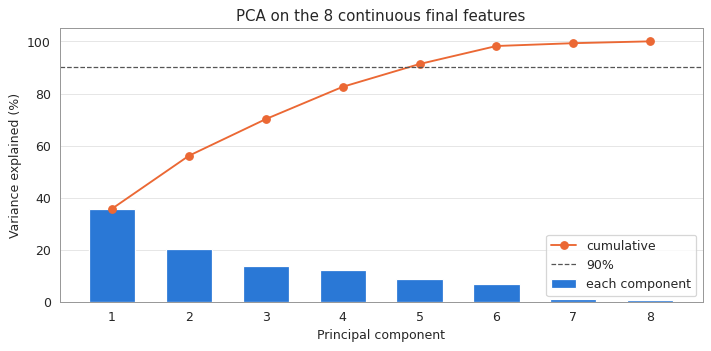

In [18]:
continuous = []
for col in selected:
    if final[col].nunique() > 3:
        continuous.append(col)
print('Continuous final features:', continuous)

pca = PCA()
pca.fit(final[continuous])
cumulative = np.cumsum(pca.explained_variance_ratio_)
n_for_90 = int(np.argmax(cumulative >= 0.90) + 1)
print('Cumulative variance:', cumulative.round(3).tolist())
print('Components needed for 90% of variance:', n_for_90, 'out of', len(continuous))

plt.figure(figsize=(8, 4))
x = np.arange(1, len(cumulative) + 1)
plt.bar(x, pca.explained_variance_ratio_ * 100, color=MAIN_COLOR, width=0.6, label='each component')
plt.plot(x, cumulative * 100, color=SECOND_COLOR, marker='o', label='cumulative')
plt.axhline(90, color='#555555', linestyle='--', linewidth=1, label='90%')
plt.xlabel('Principal component')
plt.ylabel('Variance explained (%)')
plt.title('PCA on the 8 continuous final features')
plt.legend()
plt.gca().xaxis.grid(False)
save_plot('p4_pca_variance.png')

**Result (PCA):** PCA needs **5 of the 8** components to keep 90% of the variance (35.8%, 56.1%, 70.2%, 82.6%, 91.3%). That is only a small reduction.
Each component is a mix of all features, so a decision-tree path such as "PC1 ≤ 0.3" would mean nothing to a loan officer.
This breaks the project goal of a **traceable decision path**. **Decision: PCA is not used.**

## Part E: Save the final dataset and check it

In [19]:
final_path = os.path.join(FINAL_DIR, 'final_preprocessed_dataset.csv')
final.to_csv(final_path, index=False)
print('Saved:', final_path, final.shape)
print('Missing values:', final.isnull().sum().sum())
print('Text columns:', list(final.select_dtypes(exclude='number').columns))
print()
print(final.describe().T[['mean', 'std', 'min', 'max']].round(3))

Saved: ../data/final/final_preprocessed_dataset.csv (9847, 16)
Missing values: 0
Text columns: ['loan_id']

                      mean    std    min    max
work_experience     -0.000  1.000 -1.612  4.395
total_income        -0.000  1.000 -2.300  2.422
cibil_score         -0.000  1.000 -4.710  2.603
is_new_to_credit     0.061  0.239  0.000  1.000
loan_tenure_months   0.000  1.000 -1.864  1.998
foir                 0.000  1.000 -1.887  4.134
collateral_coverage  0.000  1.000 -1.105  5.191
loan_to_income       0.000  1.000 -1.561  2.481
age_at_maturity     -0.000  1.000 -2.236  4.492
emp_senp             0.244  0.430  0.000  1.000
emp_sep              0.151  0.358  0.000  1.000
loan_type_business   0.164  0.370  0.000  1.000
loan_type_home       0.280  0.449  0.000  1.000
loan_type_vehicle    0.235  0.424  0.000  1.000
loan_status          0.585  0.493  0.000  1.000


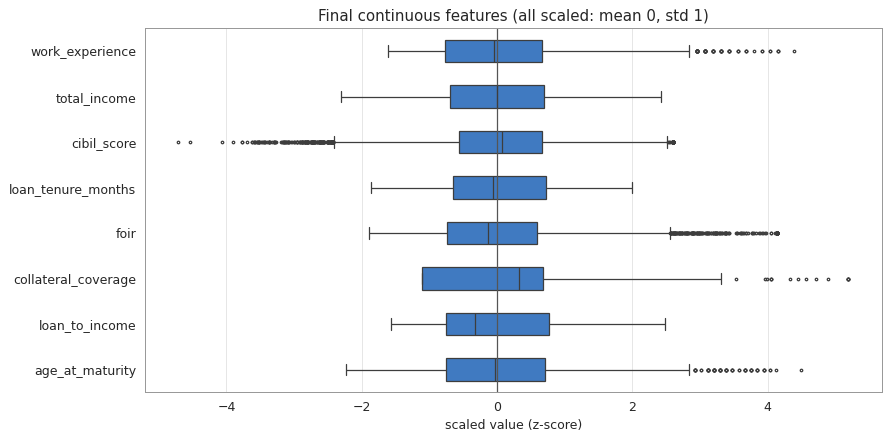

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=final[continuous], orient='h', color=MAIN_COLOR, width=0.5, flierprops={'markersize': 2})
plt.axvline(0, color='#555555', linewidth=1)
plt.title('Final continuous features (all scaled: mean 0, std 1)')
plt.xlabel('scaled value (z-score)')
save_plot('p4_final_features.png')

In [21]:
# compare with the dataset agreed at the start of the project
reference_path = '../data/reference/loan_applications_final.csv'
if os.path.exists(reference_path):
    reference = pd.read_csv(reference_path)
    print('Same columns          :', list(final.columns) == list(reference.columns))
    print('Same shape            :', final.shape == reference.shape)
    saved = pd.read_csv(final_path)
    print('Same values (exactly) :', saved.equals(reference))
else:
    print('Reference file not found - skipped.')

Same columns          : True
Same shape            : True
Same values (exactly) : True


In [22]:
# save how every final feature was made (needed to explain decisions in rupees later)
info = {
    'yearly_rate_for_emi': yearly_rate,
    'caps': caps,
    'must_keep': must_keep,
    'dropped_features': dropped,
    'selected_features': selected,
    'group_permutation_importance': group_pi,
    'cv_accuracy_all_candidates': round(float(acc_all), 4),
    'cv_accuracy_selected': round(float(acc_selected), 4),
    'pca_components_for_90_percent': n_for_90,
    'features': feature_params,
    'protected_audit_only': protected_cols,
    'scikit_learn_version': sklearn.__version__,
}
with open('feature_params.json', 'w') as f:
    json.dump(info, f, indent=2)
print('Saved: phase4/feature_params.json')

print()
print('How to read a decision-tree split in real units (new features):')
for col in ['foir', 'total_income', 'loan_to_income', 'collateral_coverage', 'age_at_maturity']:
    p = feature_params[col]
    if p['log1p']:
        print('  ', col, ': real = exp(z *', round(p['std'], 4), '+', round(p['mean'], 4), ') - 1')
    else:
        print('  ', col, ': real = z *', round(p['std'], 4), '+', round(p['mean'], 4))

Saved: phase4/feature_params.json

How to read a decision-tree split in real units (new features):
   foir : real = exp(z * 0.151 + 0.292 ) - 1
   total_income : real = exp(z * 0.6872 + 11.1275 ) - 1
   loan_to_income : real = exp(z * 0.464 + 0.7391 ) - 1
   collateral_coverage : real = z * 0.7942 + 0.8773
   age_at_maturity : real = z * 10.8499 + 45.2643


### Phase 4 summary

- **Final dataset:** `data/final/final_preprocessed_dataset.csv`, **9,847 rows × 16 columns** (`loan_id` + 14 features + `loan_status`), with no missing values.
  It is **exactly the same** as the dataset agreed at the start of the project.
- **14 features:**
  - 8 continuous (scaled): work_experience, total_income, cibil_score, loan_tenure_months, foir, collateral_coverage, loan_to_income, age_at_maturity
  - 6 binary: is_new_to_credit, emp_senp, emp_sep, loan_type_business, loan_type_home, loan_type_vehicle
- **`loan_id` must be dropped before `fit()`.** It is kept to join predictions to the audit log and to the protected attributes for the fairness audit.
- `feature_params.json` stores the formulas, caps and scaler values, so a tree split can be read in real units.
  For example, a FOIR split at z = 0.5 means **FOIR ≈ 44%**.